In [2]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface
from tqdm import tqdm


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [97]:
recording = []
for date in ['20240115']:#, '20240115']:
    recording.append(se.read_blackrock(f'/media/ubuntu/sda/Monkey/TVSD/monkeyF/{date}/Block_1/Hub1-instance2_B001.ns6'))

In [98]:
recording_full = si.concatenate_recordings(recording)

In [99]:
from probeinterface import write_probeinterface, read_probeinterface
probe_30channel = read_probeinterface('/media/ubuntu/sda/Monkey/scripts/sua/probe_256.json')
probe_30channel.set_global_device_channel_indices([i for i in range(256)])
recording_recorded = recording_full.set_probegroup(probe_30channel)

In [100]:
recording_cmr = recording_recorded
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
print(recording_f)
recording_cmr = spre.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)

BandpassFilterRecording: 256 channels - 30.0kHz - 1 segments - 36,880,855 samples 
                         1,229.36s (20.49 minutes) - int16 dtype - 17.59 GiB
CommonReferenceRecording: 256 channels - 30.0kHz - 1 segments - 36,880,855 samples 
                          1,229.36s (20.49 minutes) - int16 dtype - 17.59 GiB


In [101]:
recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)
os.makedirs(f"/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day2", exist_ok=True)
output_folder = f"/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day2"
sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
            "random_spikes",
            "waveforms",
            "noise_levels",
            "templates",
            "spike_amplitudes",
            "unit_locations",
            "spike_locations",
            "correlograms",
            "template_similarity"
        ]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

Use cache_folder=/tmp/spikeinterface_cache/tmpfwayb6xb/KSS091E5
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=14.65 MiB - total_memory=14.65 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization): 100%|██████████| 1230/1230 [03:34<00:00,  5.74it/s]


BinaryFolderRecording: 256 channels - 30.0kHz - 1 segments - 36,880,855 samples 
                       1,229.36s (20.49 minutes) - int16 dtype - 17.59 GiB


estimate_sparsity (no parallelization): 100%|██████████| 1230/1230 [00:00<00:00, 4261.67it/s]
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/spikeinterface/core/basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")
noise_level (no parallelization): 100%|██████████| 20/20 [00:01<00:00, 13.84it/s]
Compute : spike_amplitudes + spike_locations (no parallelization): 100%|██████████| 1230/1230 [00:47<00:00, 25.69it/s]
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/spikeinterface/qualitymetrics/misc_metrics.py:1066: UserWarning: Some units have too few spikes : amplitude_cutoff is set to NaN
  warnings.warn(f"Some units have too few spikes : amplitude_cutoff is set to NaN")
/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning:

Run:
phy template-gui  /media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day2/phy_folder_for_kilosort/params.py


In [5]:
import os
import re
import glob
import numpy as np
import pandas as pd
import numpy as np
import scipy.io as sio
import spikeinterface.extractors as se
import spikeinterface as si
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
from pathlib import Path
import matplotlib.pyplot as plt
import json

from typing import List, Tuple


ROOT_SORT_DIR = "/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day1/phy_folder_for_kilosort"

# 需要的 cluster 指标文件（来自 phy_folder_for_kilosort）
CLUSTER_INFO_FILENAME = "cluster_info.tsv"

SPIKE_CLUSTERS_FILENAME = "spike_clusters.npy"
SPIKE_TIMES_FILENAME = "spike_times.npy"

In [6]:
def load_cluster_info(phy_dir: str) -> pd.DataFrame:
    """读取 phy_folder_for_kilosort/cluster_info.tsv 为 DataFrame。
    该表包含所有需要的 cluster 级指标。
    如果cluster_info.tsv不存在，则尝试从其他文件构建基本信息。
    同时计算并添加mean_waveform信息。
    """
    path = os.path.join(phy_dir, CLUSTER_INFO_FILENAME)
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        # 标准化主键列名
        if 'cluster_id' not in df.columns:
            raise ValueError(f"{path} 中缺少 cluster_id 列")
    else:
        print(f"警告: {path} 不存在，尝试从其他文件构建cluster信息")
        
        # 尝试从cluster_group.tsv构建基本信息
        cluster_group_path = os.path.join(phy_dir, "cluster_group.tsv")
        if os.path.exists(cluster_group_path):
            df = pd.read_csv(cluster_group_path, sep='\t')
            if 'cluster_id' not in df.columns:
                raise ValueError(f"{cluster_group_path} 中缺少 cluster_id 列")
        else:
            # 如果都没有，从spike_clusters.npy中提取唯一的cluster_id
            spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
            if os.path.exists(spike_clusters_path):
                spike_clusters = np.load(spike_clusters_path)
                unique_clusters = np.unique(spike_clusters)
                df = pd.DataFrame({
                    'cluster_id': unique_clusters,
                    'group': 'unsorted'  # 默认分组
                })
            else:
                raise ValueError(f"无法找到任何cluster信息文件: {phy_dir}")
    
    # 计算mean_waveform并展开为多列添加到DataFrame
    mean_waveforms = compute_mean_waveform(phy_dir)
    if mean_waveforms:
        # 确定waveform的长度（通常是90个时间点）
        waveform_length = None
        for waveform in mean_waveforms.values():
            if waveform is not None:
                waveform_length = len(waveform)
                break
        
        if waveform_length is not None:
            # 创建waveform列名
            waveform_columns = [f'mean_waveform_{i}' for i in range(waveform_length)]
            
            # 为每个cluster创建waveform数据
            waveform_data = {}
            for cluster_id in df['cluster_id']:
                if cluster_id in mean_waveforms and mean_waveforms[cluster_id] is not None:
                    waveform = mean_waveforms[cluster_id]
                    # 确保waveform长度一致
                    if len(waveform) == waveform_length:
                        waveform_data[cluster_id] = waveform
                    else:
                        # 如果长度不匹配，用NaN填充或截断
                        padded_waveform = np.full(waveform_length, np.nan)
                        padded_waveform[:min(len(waveform), waveform_length)] = waveform[:min(len(waveform), waveform_length)]
                        waveform_data[cluster_id] = padded_waveform
                else:
                    # 没有waveform数据的cluster用NaN填充
                    waveform_data[cluster_id] = np.full(waveform_length, np.nan)
            
            # 将waveform数据转换为DataFrame并合并
            waveform_df = pd.DataFrame.from_dict(waveform_data, orient='index', columns=waveform_columns)
            waveform_df.index.name = 'cluster_id'
            waveform_df = waveform_df.reset_index()
            
            # 合并到主DataFrame
            df = df.merge(waveform_df, on='cluster_id', how='left')
            print(f"成功添加mean_waveform信息到 {len(mean_waveforms)} 个clusters，展开为 {waveform_length} 列")
        else:
            print("警告: 无法确定waveform长度")
    else:
        print("警告: 无法计算mean_waveform信息")
    
    return df


def load_spike_level(phy_dir: str) -> pd.DataFrame:
    """读取 spike 层面的 numpy 文件并返回 DataFrame: [cluster, time]
    time 使用原始采样点，不做单位转换。
    """
    spike_clusters = np.load(os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME))
    spike_times = np.load(os.path.join(phy_dir, SPIKE_TIMES_FILENAME))
    # 展平为一维
    spike_clusters = np.asarray(spike_clusters).reshape(-1)
    spike_times = np.asarray(spike_times).reshape(-1)
    if spike_clusters.shape[0] != spike_times.shape[0]:
        raise ValueError(f"spike_clusters 与 spike_times 行数不一致: {phy_dir}")
    df = pd.DataFrame({
        'cluster_id': spike_clusters.astype(int),
        'time': spike_times.astype(int),
    })
    return df


def compute_mean_waveform(phy_dir: str) -> dict:
    """计算每个cluster的平均波形
    
    Returns:
        dict: {cluster_id: mean_waveform_array}
    """
    templates_path = os.path.join(phy_dir, "templates.npy")
    spike_templates_path = os.path.join(phy_dir, "spike_templates.npy")
    spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
    
    if not all(os.path.exists(p) for p in [templates_path, spike_templates_path, spike_clusters_path]):
        print("警告: 缺少计算waveform所需的文件，跳过mean_waveform计算")
        return {}
    
    # 加载数据
    templates = np.load(templates_path)  # shape: (n_templates, n_timepoints, n_channels)
    spike_templates = np.load(spike_templates_path).flatten()  # shape: (n_spikes,)
    spike_clusters = np.load(spike_clusters_path).flatten()  # shape: (n_spikes,)
    
    # 创建cluster到template的映射
    cluster_template_map = {}
    for spike_idx, (cluster_id, template_id) in enumerate(zip(spike_clusters, spike_templates)):
        if cluster_id not in cluster_template_map:
            cluster_template_map[cluster_id] = template_id
    
    # 计算每个cluster的mean_waveform
    mean_waveforms = {}
    for cluster_id, template_id in cluster_template_map.items():
        if template_id < templates.shape[0]:
            # 获取该cluster对应的template
            template = templates[template_id]  # shape: (n_timepoints, n_channels)
            # 如果模板是2D的，取第一个通道或平均所有通道
            if template.ndim == 2:
                if template.shape[1] == 1:
                    # 只有一个通道
                    mean_waveform = template[:, 0]
                else:
                    # 多个通道，取平均
                    mean_waveform = np.mean(template, axis=1)
            else:
                # 1D情况
                mean_waveform = template
            mean_waveforms[cluster_id] = mean_waveform
    
    return mean_waveforms

In [11]:
ROOT_SORT_DIR = "/media/ubuntu/sda/Monkey/data/sorted/Block_1_Hub1_instance2_day1/phy_folder_for_kilosort"
cluster_inf_all = load_cluster_info(phy_dir=ROOT_SORT_DIR)
spike_inf_all = load_spike_level(phy_dir=ROOT_SORT_DIR)

cluster_inf_all = cluster_inf_all[(cluster_inf_all['group'] == 'good')]
spike_inf_all = spike_inf_all[spike_inf_all['cluster_id'].isin(cluster_inf_all['cluster_id'].values)]
cluster_inf_all['date'] = 1
spike_inf_all['date'] = 1


ROOT_SORT_DIR = "/media/ubuntu/sda/Monkey/data/sorted/Block_2_Hub1_instance2_day1/phy_folder_for_kilosort"
cluster_inf = load_cluster_info(phy_dir=ROOT_SORT_DIR)
spike_inf = load_spike_level(phy_dir=ROOT_SORT_DIR)

cluster_inf = cluster_inf[(cluster_inf['group'] == 'good')]
spike_inf = spike_inf[spike_inf['cluster_id'].isin(cluster_inf['cluster_id'].values)]
cluster_inf['date'] = 2
spike_inf['date'] = 2

cluster_inf_all = pd.concat((cluster_inf_all, cluster_inf), axis = 0)
spike_inf_all = pd.concat((spike_inf_all, spike_inf), axis = 0)

成功添加mean_waveform信息到 280 个clusters，展开为 90 列
成功添加mean_waveform信息到 220 个clusters，展开为 90 列


In [8]:
from quantities import s
from elephant.statistics import instantaneous_rate
from elephant.kernels import GaussianKernel
import neo
gk = GaussianKernel(120 * s)
rates = {}
for cluster in spike_inf['cluster_id'].unique():
    spike_train = spike_inf[spike_inf['cluster_id'] == cluster]['time'].values
    spike_train = spike_train / 30000
    temp_spiketrain = neo.SpikeTrain(spike_train.astype(int) * s, t_stop=2476, t_start=0)
    rates[cluster] = instantaneous_rate(temp_spiketrain, kernel=gk, sampling_period=60*s).magnitude.flatten()

In [12]:
from scipy.stats import pearsonr

def match_clusters_across_dates(cluster_inf_all, corr_threshold=0.95):
    """
    根据channel和waveform相似度匹配不同日期的clusters
    注意：同一个channel在同一天可能有多个clusters
    
    Parameters:
    -----------
    cluster_inf_all : DataFrame
        包含所有日期的cluster信息，必须有以下列：
        - date: 日期（1或2）
        - ch: channel编号
        - cluster_id: cluster ID
        - mean_waveform_0 到 mean_waveform_N: 平均波形
    corr_threshold : float
        Pearson相关系数阈值，默认0.95
    
    Returns:
    --------
    cluster_inf_all : DataFrame
        添加了neuron列，标记同一神经元
    matching_info : dict
        匹配信息统计
    """
    
    print(f"开始匹配跨日期clusters...")
    print(f"相关性阈值: {corr_threshold}")
    
    # 获取waveform列名
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]
    print(f"Waveform维度: {len(waveform_cols)}")
    
    # 分离两个日期的数据
    df_date1 = cluster_inf_all[cluster_inf_all['date'] == 1].copy().reset_index(drop=True)
    df_date2 = cluster_inf_all[cluster_inf_all['date'] == 2].copy().reset_index(drop=True)
    
    print(f"Date 1 clusters: {len(df_date1)}")
    print(f"Date 2 clusters: {len(df_date2)}")
    
    # 统计每个channel的cluster数量
    ch_counts_d1 = df_date1['ch'].value_counts()
    ch_counts_d2 = df_date2['ch'].value_counts()
    multi_cluster_chs = set(ch_counts_d1[ch_counts_d1 > 1].index) | set(ch_counts_d2[ch_counts_d2 > 1].index)
    print(f"有多个clusters的channels数量: {len(multi_cluster_chs)}")
    
    # 初始化neuron ID
    cluster_inf_all['neuron'] = -1
    neuron_id = 0
    
    # 记录已匹配的indices
    matched_date1 = set()
    matched_date2 = set()
    matched_pairs = []
    
    # 创建所有可能的匹配对及其相关性
    potential_matches = []
    
    print("\n计算所有潜在匹配对的相关性...")
    for idx1, row1 in tqdm(df_date1.iterrows(), total=len(df_date1), desc="扫描Date 1"):
        ch1 = row1['ch']
        waveform1 = row1[waveform_cols].values.astype(float)
        
        # 检查waveform是否有效
        if np.isnan(waveform1).all():
            continue
        
        # 在date2中找到相同channel的clusters
        candidates = df_date2[df_date2['ch'] == ch1]
        
        for idx2, row2 in candidates.iterrows():
            waveform2 = row2[waveform_cols].values.astype(float)
            
            # 检查waveform是否有效
            if np.isnan(waveform2).all():
                continue
            
            # 计算pearson相关性
            valid_mask = ~(np.isnan(waveform1) | np.isnan(waveform2))
            if valid_mask.sum() > 10:
                corr, _ = pearsonr(waveform1[valid_mask], waveform2[valid_mask])
                
                if corr >= corr_threshold:
                    potential_matches.append({
                        'idx1': idx1,
                        'idx2': idx2,
                        'cluster_id1': row1['cluster_id'],
                        'cluster_id2': row2['cluster_id'],
                        'ch': ch1,
                        'correlation': corr
                    })
    
    print(f"找到 {len(potential_matches)} 个潜在匹配对（相关性 >= {corr_threshold}）")
    
    # 按相关性降序排序，优先匹配相关性最高的
    potential_matches.sort(key=lambda x: x['correlation'], reverse=True)
    
    # 贪心匹配：从相关性最高的开始，确保每个cluster只匹配一次
    print("\n执行贪心匹配...")
    for match in tqdm(potential_matches, desc="匹配clusters"):
        idx1 = match['idx1']
        idx2 = match['idx2']
        
        # 如果两个cluster都还没被匹配
        if idx1 not in matched_date1 and idx2 not in matched_date2:
            # 获取原始DataFrame的索引
            orig_idx1 = df_date1.loc[idx1, 'cluster_id']
            orig_idx2 = df_date2.loc[idx2, 'cluster_id']
            
            # 找到原始DataFrame中的位置
            mask1 = (cluster_inf_all['cluster_id'] == orig_idx1) & (cluster_inf_all['date'] == 1)
            mask2 = (cluster_inf_all['cluster_id'] == orig_idx2) & (cluster_inf_all['date'] == 2)
            
            # 分配相同的neuron ID
            cluster_inf_all.loc[mask1, 'neuron'] = neuron_id
            cluster_inf_all.loc[mask2, 'neuron'] = neuron_id
            
            matched_pairs.append({
                'neuron_id': neuron_id,
                'date1_cluster': match['cluster_id1'],
                'date2_cluster': match['cluster_id2'],
                'ch': match['ch'],
                'correlation': match['correlation']
            })
            
            matched_date1.add(idx1)
            matched_date2.add(idx2)
            neuron_id += 1
    
    # 为未匹配的clusters分配独立的neuron ID
    for idx1 in range(len(df_date1)):
        if idx1 not in matched_date1:
            orig_idx = df_date1.loc[idx1, 'cluster_id']
            mask = (cluster_inf_all['cluster_id'] == orig_idx) & (cluster_inf_all['date'] == 1)
            cluster_inf_all.loc[mask, 'neuron'] = neuron_id
            neuron_id += 1
    
    for idx2 in range(len(df_date2)):
        if idx2 not in matched_date2:
            orig_idx = df_date2.loc[idx2, 'cluster_id']
            mask = (cluster_inf_all['cluster_id'] == orig_idx) & (cluster_inf_all['date'] == 2)
            cluster_inf_all.loc[mask, 'neuron'] = neuron_id
            neuron_id += 1
    
    # 统计信息
    matching_info = {
        'total_neurons': neuron_id,
        'matched_pairs': len(matched_pairs),
        'unmatched_date1': len(df_date1) - len(matched_date1),
        'unmatched_date2': len(df_date2) - len(matched_date2),
        'multi_cluster_channels': len(multi_cluster_chs),
        'matching_details': matched_pairs
    }
    
    print(f"\n{'='*60}")
    print(f"匹配完成！")
    print(f"{'='*60}")
    print(f"总神经元数量: {neuron_id}")
    print(f"成功匹配的cluster对: {len(matched_pairs)}")
    print(f"Date 1 未匹配: {len(df_date1) - len(matched_date1)}")
    print(f"Date 2 未匹配: {len(df_date2) - len(matched_date2)}")
    print(f"有多个clusters的channels: {len(multi_cluster_chs)}")
    if matched_pairs:
        print(f"平均匹配相关性: {np.mean([p['correlation'] for p in matched_pairs]):.4f}")
        print(f"匹配相关性范围: [{np.min([p['correlation'] for p in matched_pairs]):.4f}, {np.max([p['correlation'] for p in matched_pairs]):.4f}]")
    print(f"{'='*60}\n")
    
    return cluster_inf_all, matching_info

# 使用示例（取消注释以运行）
cluster_inf_match, matching_info = match_clusters_across_dates(cluster_inf_all, corr_threshold=0.95)


开始匹配跨日期clusters...
相关性阈值: 0.95
Waveform维度: 90
Date 1 clusters: 85
Date 2 clusters: 72
有多个clusters的channels数量: 7

计算所有潜在匹配对的相关性...


扫描Date 1: 100%|██████████| 85/85 [00:00<00:00, 2637.19it/s]


找到 42 个潜在匹配对（相关性 >= 0.95）

执行贪心匹配...


匹配clusters: 100%|██████████| 42/42 [00:00<00:00, 4189.72it/s]


匹配完成！
总神经元数量: 120
成功匹配的cluster对: 37
Date 1 未匹配: 48
Date 2 未匹配: 35
有多个clusters的channels: 7
平均匹配相关性: 0.9894
匹配相关性范围: [0.9583, 0.9998]



绘制Date 1的waveform网格图...
布局: 16×16 = 256 channels
该日期的clusters: 85
其中能跨天追踪的: 37
已保存: waveform_grid_date1.pdf


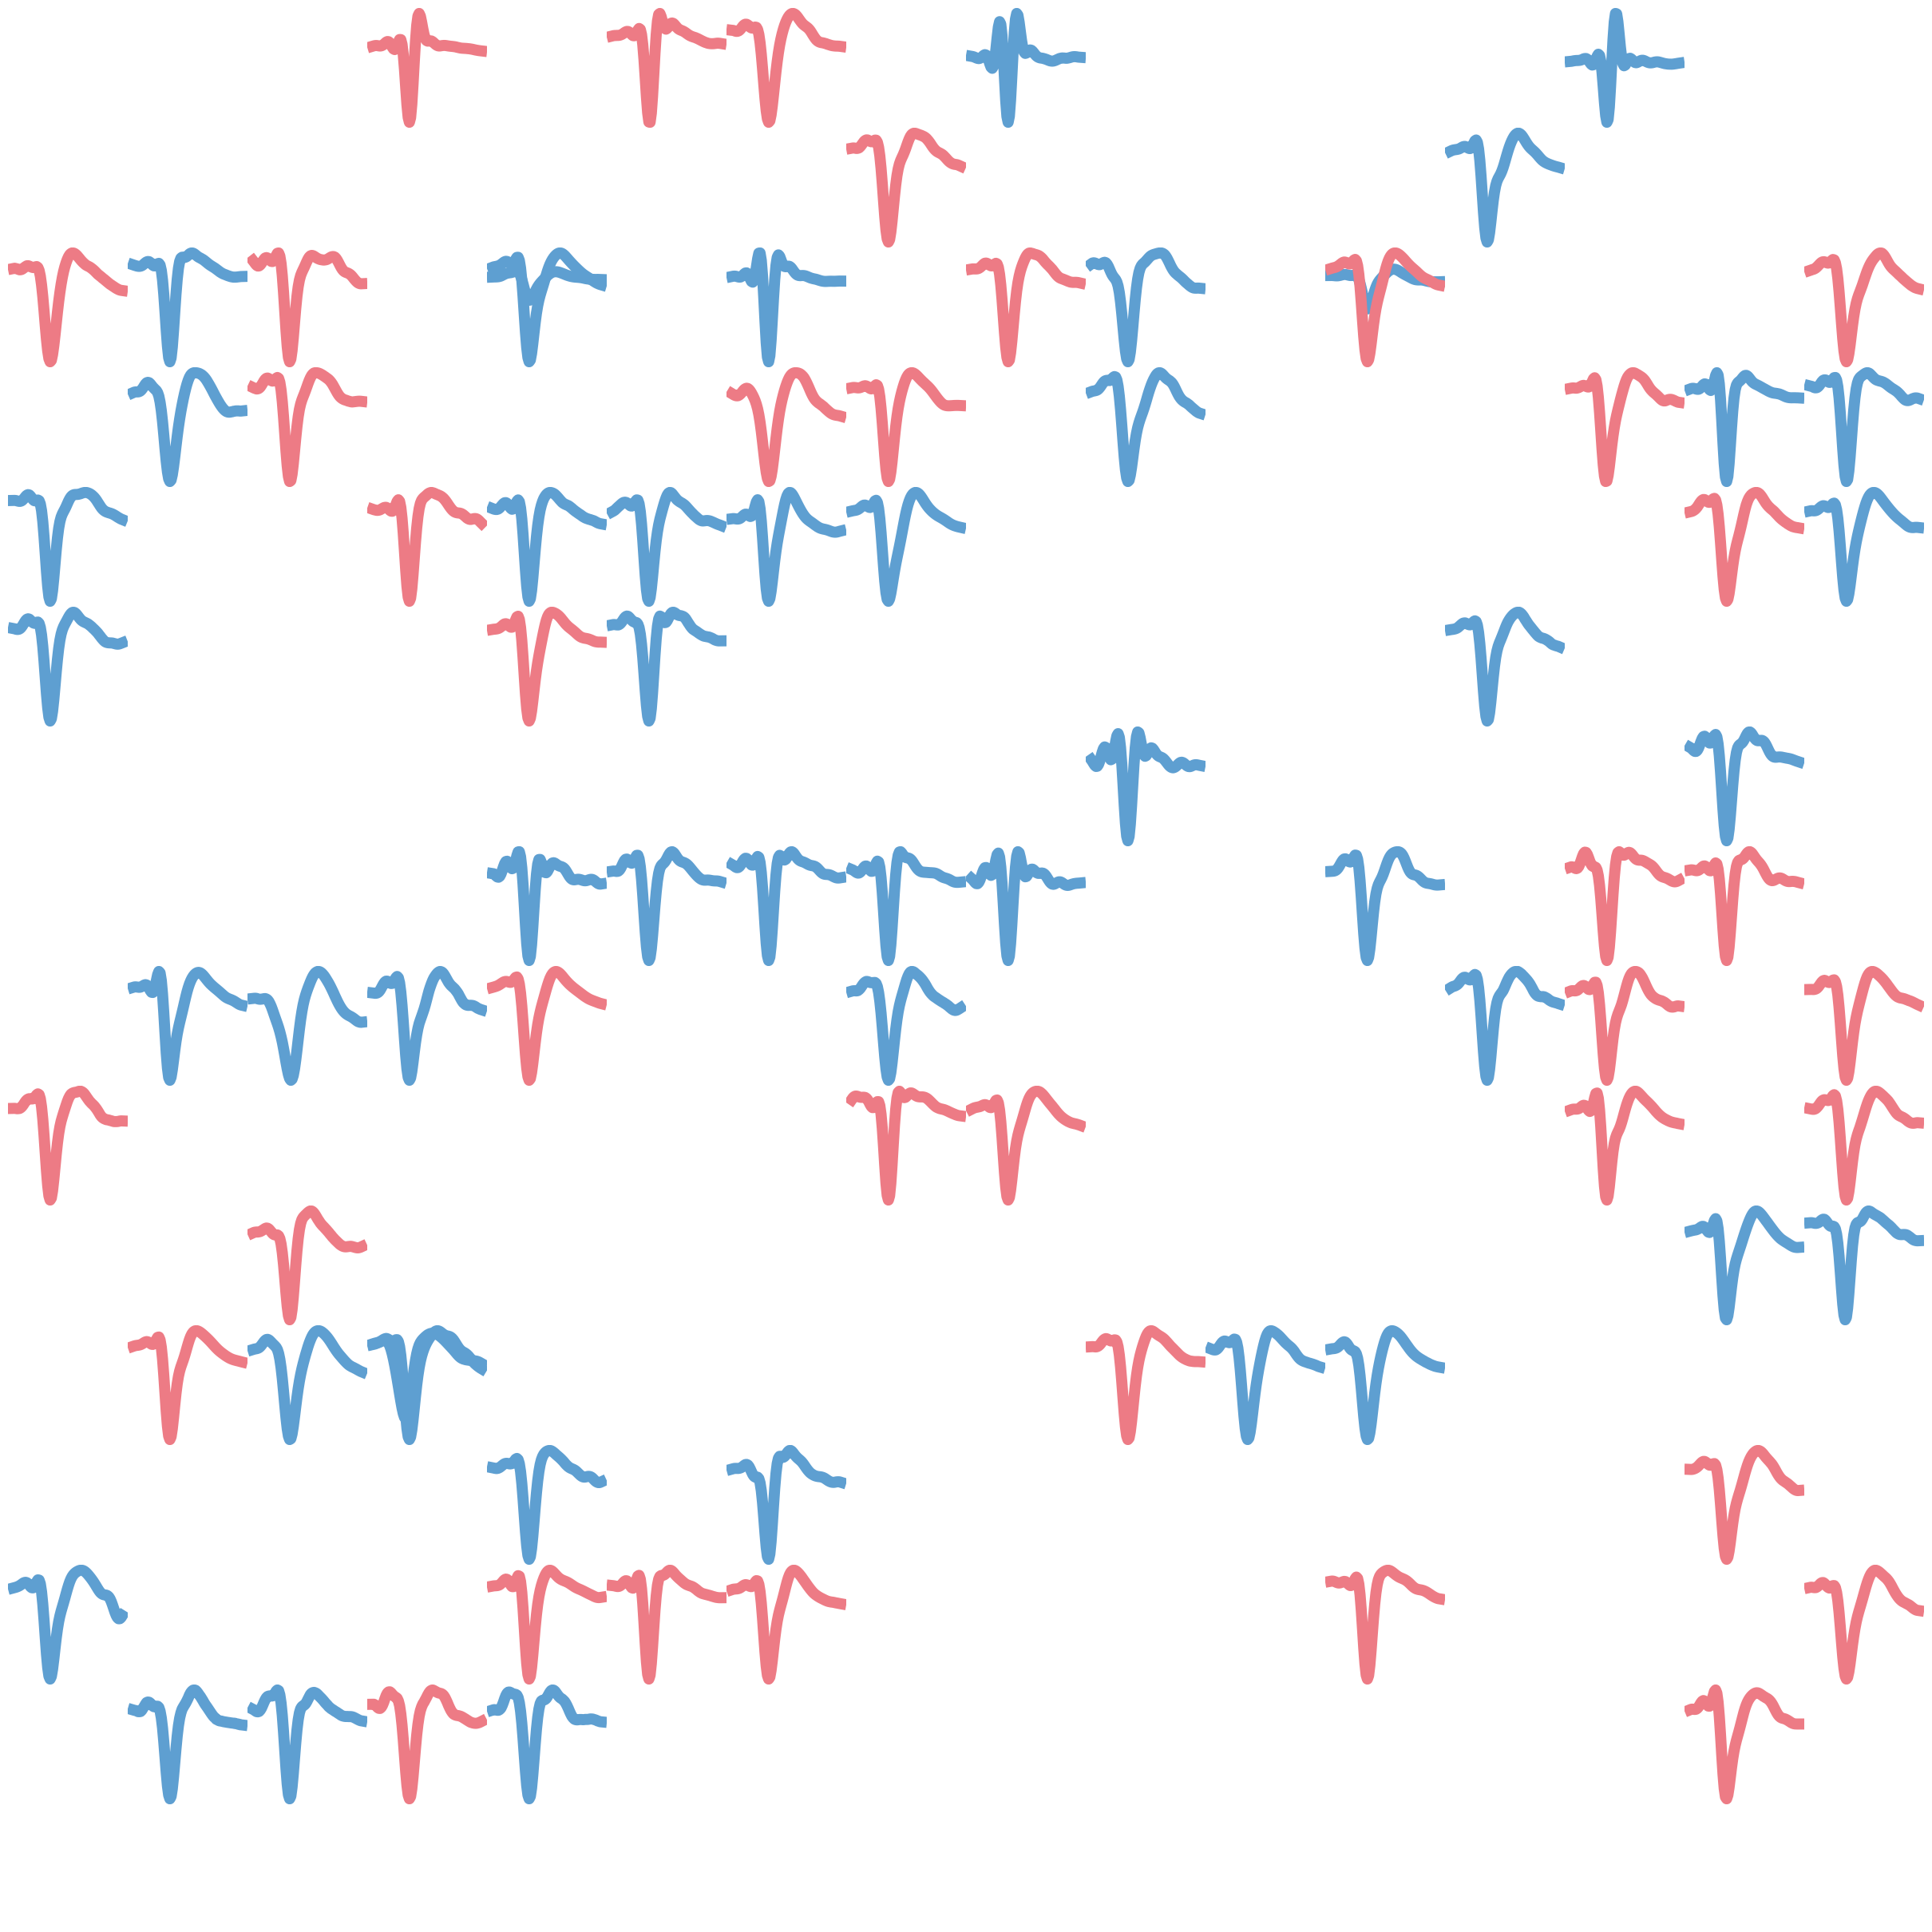

绘制Date 2的waveform网格图...
布局: 16×16 = 256 channels
该日期的clusters: 72
其中能跨天追踪的: 37
已保存: waveform_grid_date2.pdf


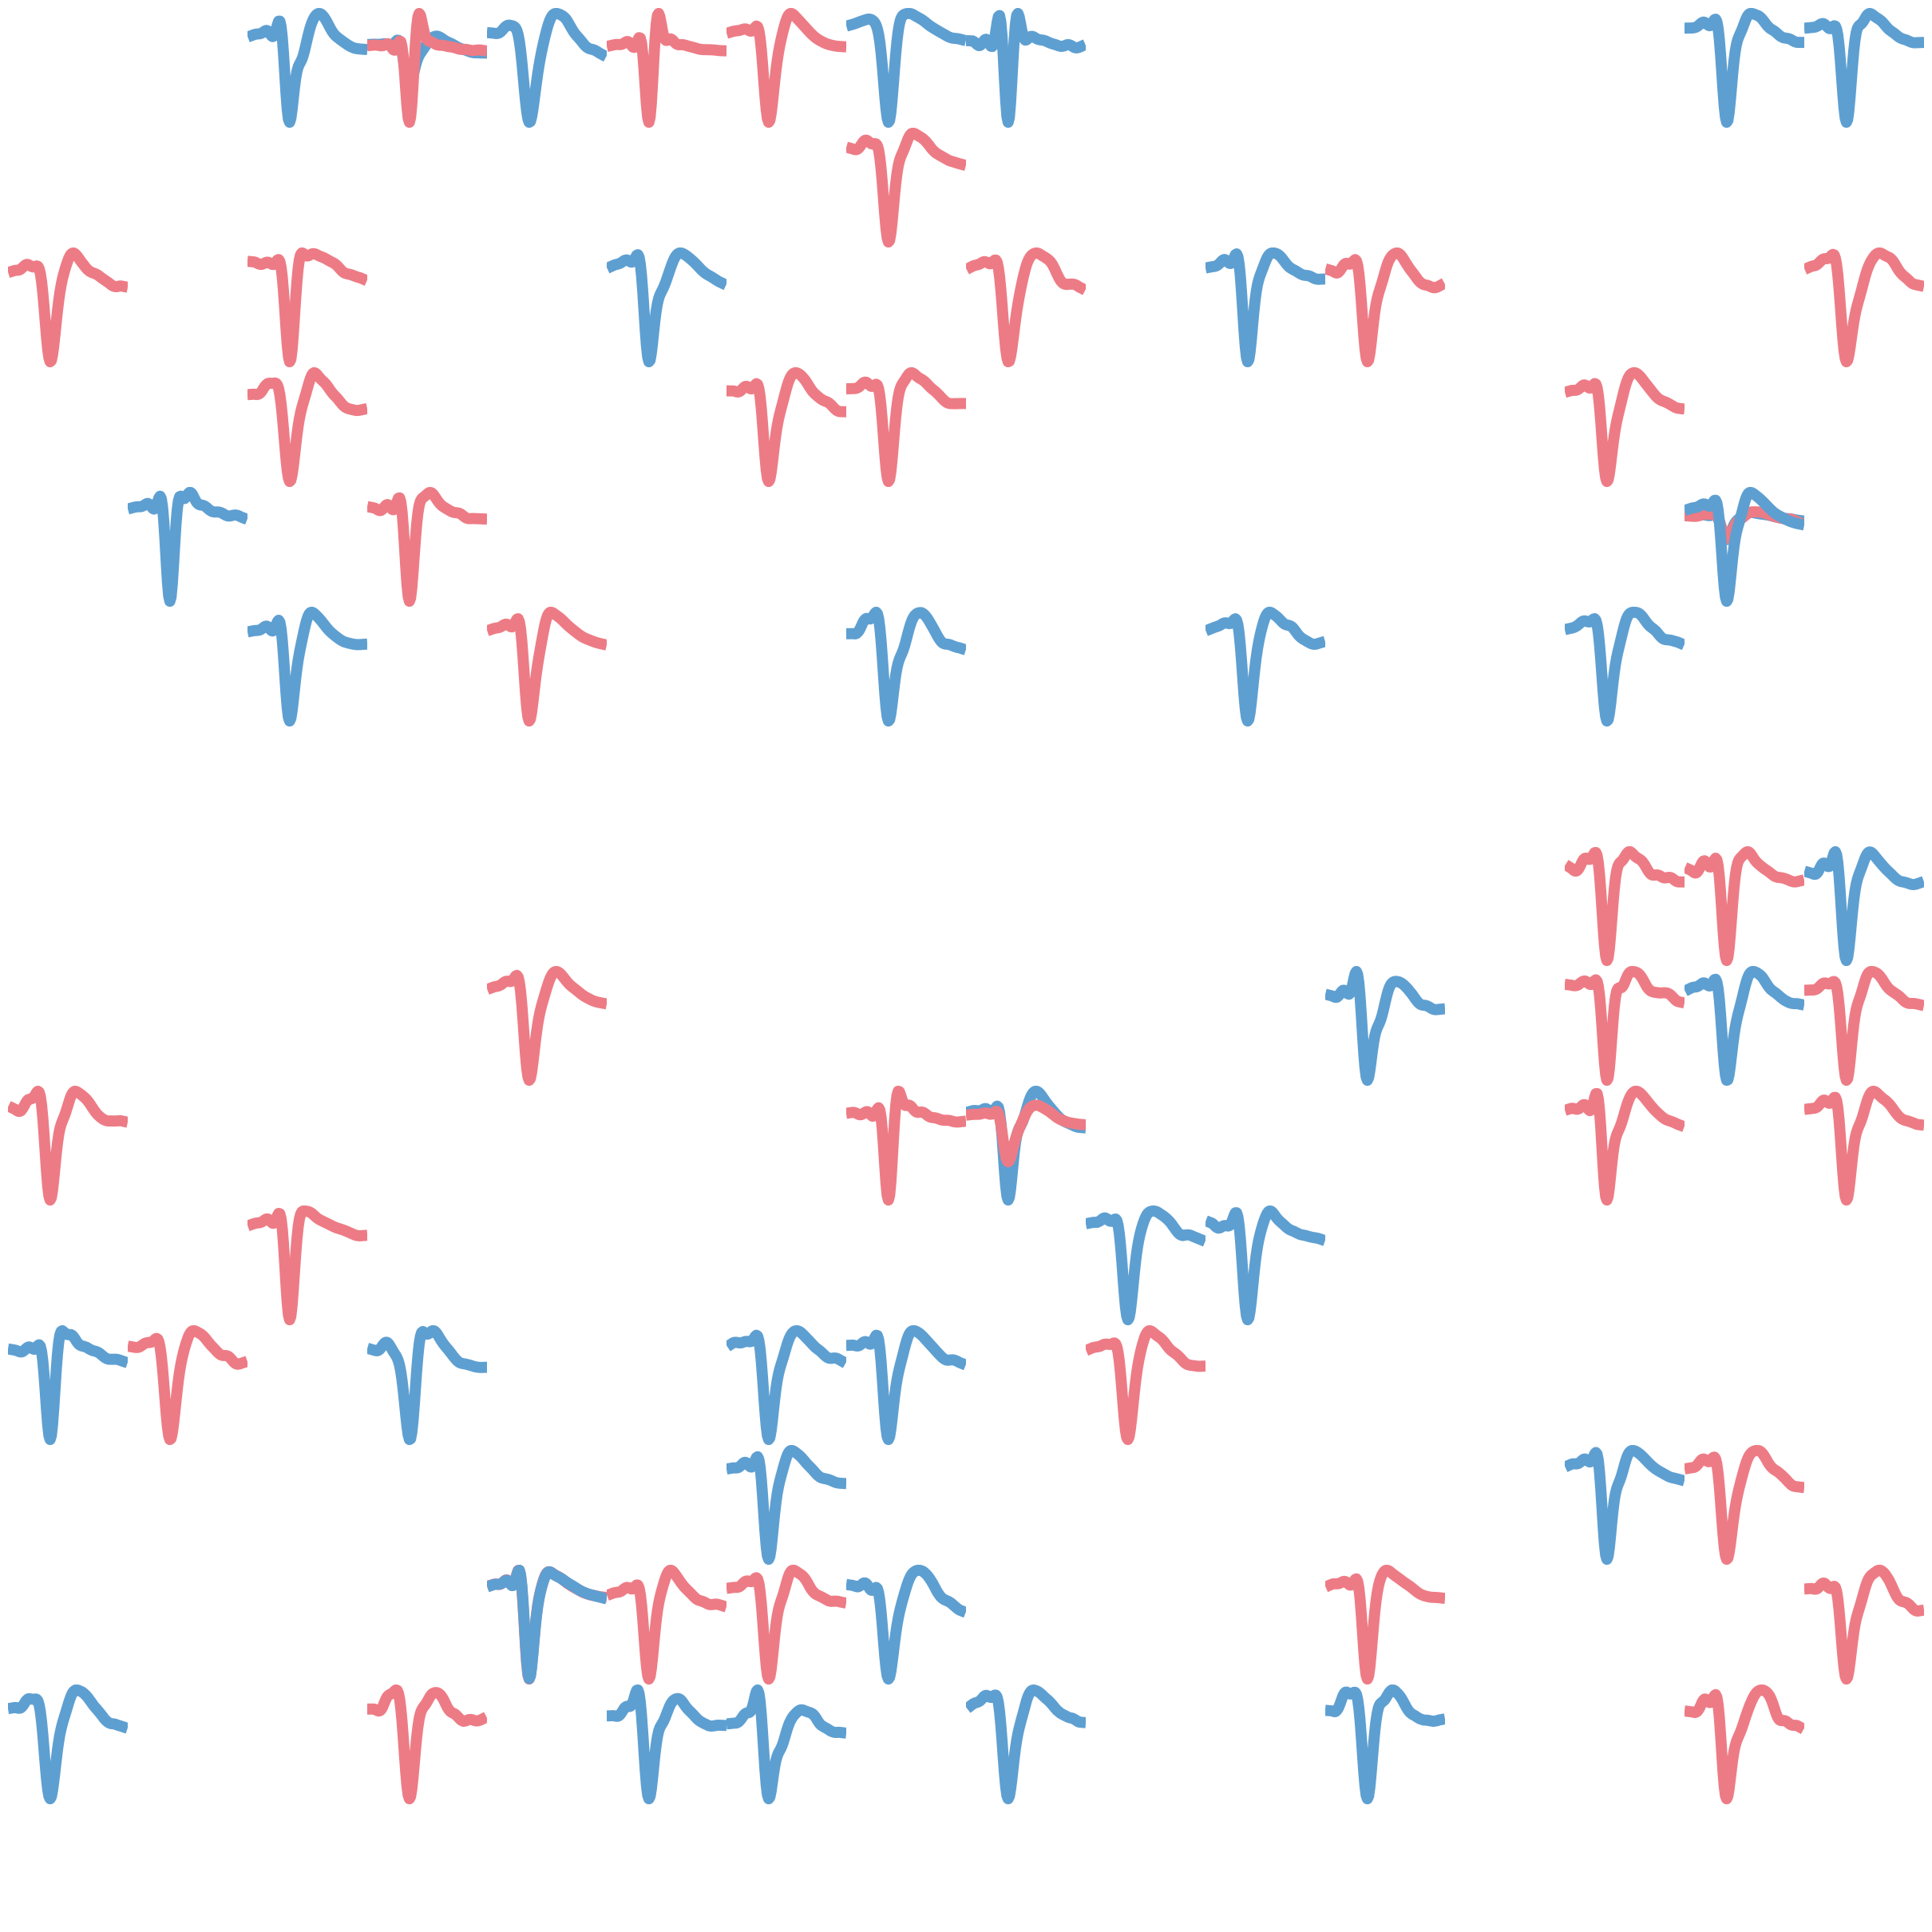

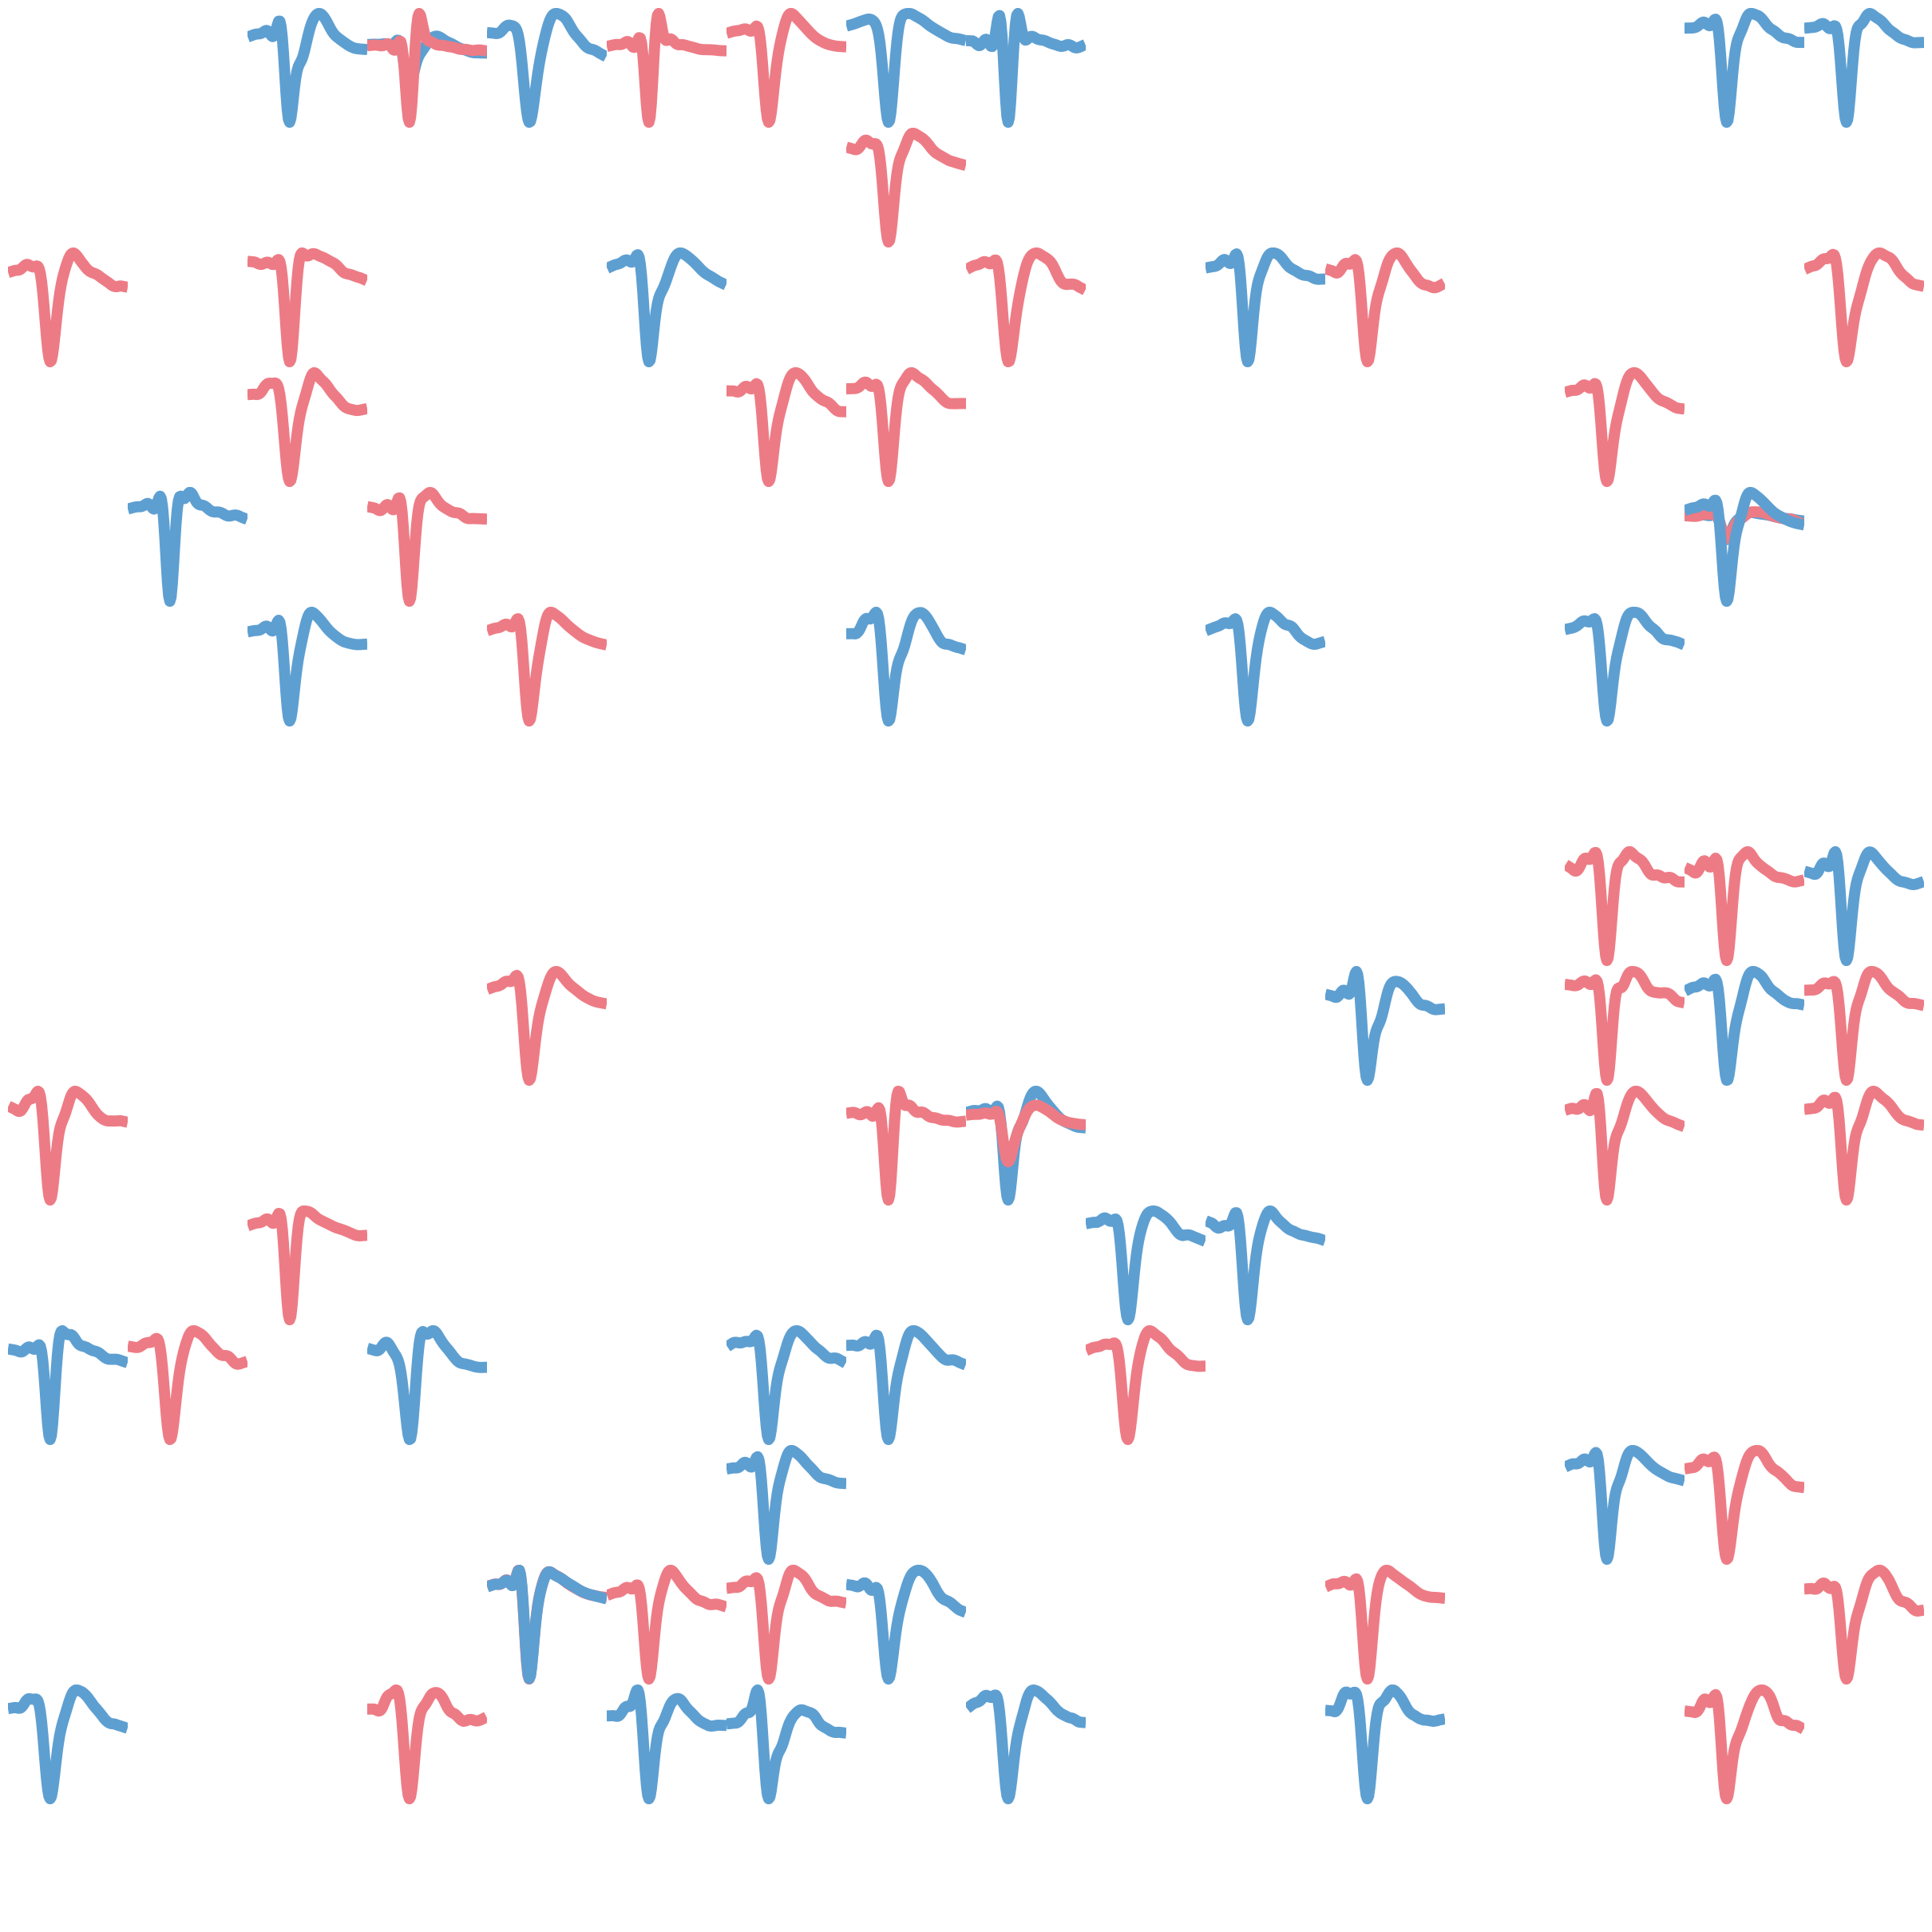

In [14]:
def plot_waveform_grid(cluster_inf_all, date, n_rows=16, n_cols=16, figsize=(24, 24), output_name=None):
    """
    绘制单个日期的waveform网格图，16×16布局，每个子图代表一个channel
    两天都能追踪到的cluster: #ED7B85（红色）
    只在当前这一天出现的cluster: #5E9FD1（蓝色）
    
    Parameters:
    -----------
    cluster_inf_all : DataFrame
        包含cluster信息和waveform数据，必须包含neuron列
    date : int
        要绘制的日期（1或2）
    n_rows : int
        行数，默认16
    n_cols : int
        列数，默认16
    figsize : tuple
        图形大小
    output_name : str
        输出PDF文件名，如果为None则不保存
    """
    
    # 筛选指定日期的数据
    df_date = cluster_inf_all[cluster_inf_all['date'] == date].copy()
    
    # 找出匹配的neuron IDs（在两天都出现的）
    neurons_date1 = set(cluster_inf_all[cluster_inf_all['date'] == 1]['neuron'].values)
    neurons_date2 = set(cluster_inf_all[cluster_inf_all['date'] == 2]['neuron'].values)
    matched_neurons = neurons_date1 & neurons_date2  # 交集
    
    # 获取waveform列
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]
    
    print(f"绘制Date {date}的waveform网格图...")
    print(f"布局: {n_rows}×{n_cols} = {n_rows*n_cols} channels")
    print(f"该日期的clusters: {len(df_date)}")
    print(f"其中能跨天追踪的: {len([n for n in df_date['neuron'].values if n in matched_neurons])}")
    
    # 创建图形
    fig = plt.figure(figsize=figsize)
    
    # 对每个channel绘制
    for ch in range(n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, ch + 1)
        
        # 获取该channel的所有clusters
        ch_clusters = df_date[df_date['ch'] == ch]
        
        if len(ch_clusters) > 0:
            # 绘制该channel的所有clusters的waveform
            for idx, row in ch_clusters.iterrows():
                waveform = row[waveform_cols].values.astype(float)
                
                # 只绘制非NaN的waveform
                if not np.isnan(waveform).all():
                    # 根据neuron是否在两天都出现选择颜色
                    if row['neuron'] in matched_neurons:
                        color = '#ED7B85'  # 红色：两天都能追踪到
                    else:
                        color = '#5E9FD1'  # 蓝色：只在当前这一天
                    
                    ax.plot(waveform, color=color, linewidth=10, alpha=1)
        
        # 删除所有坐标轴、标题、图例
        ax.axis('off')
    
    # 删除图形之间的间隙
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    
    if output_name:
        plt.savefig(output_name, dpi=150, bbox_inches='tight')
        print(f"已保存: {output_name}")
    
    plt.show()
    
    return fig


plot_waveform_grid(cluster_inf_all, date=1, output_name='waveform_grid_date1.pdf')


plot_waveform_grid(cluster_inf_all, date=2, output_name='waveform_grid_date2.pdf')
